In [554]:
# import Packages
from langgraph.graph import StateGraph, END, START
from typing import TypedDict, Annotated, List
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from langchain.tools import tool
from tavily import TavilyClient
from dotenv import load_dotenv
from pprint import pprint
from typing import Literal
import os

In [555]:
# Get Env Vars
load_dotenv()
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [556]:
# Define Agent Brain
groq_model = ChatGroq(model="llama-3.1-8b-instant", temperature=0, api_key=GROQ_API_KEY)

In [557]:
# Agent State
class AgentState(TypedDict):
    response: str
    question: str
    user_feedback: str
    status: Literal["approved", "feedback"]
    status_d: Literal["continue", "END"]

In [558]:
SYS_PROMPT = """You are a helpful AI assistant that can answer any question by searching the web if needed. 
Provide accurate, concise, and helpful responses. When you need current information, use the search tool."""

In [559]:
# Define Assistant Draft
def assistant_draft(state: AgentState):
    print("assistant_draft ...")

    # IF We Have Feedback
    if (state.get("status") == "feedback"):
        messages = [HumanMessage(state.get("user_feedback")), SystemMessage(SYS_PROMPT)]
        response = groq_model.invoke(input=messages)
        return {"response": response.content, "status_d": "END"}

    # No feedback
    else:
        messages = [HumanMessage(state["question"]), SystemMessage(SYS_PROMPT)]
        response = groq_model.invoke(input=messages)
        return {"response": response.content, "status_d": "continue"}


In [560]:
# Human Feedback Node
def human_feedback(state):
    print("human_feedback ...")
    choice = input("\nApprove? (y/n): ")

    if choice.lower() == "y":
        return {
            "status": "approved",
            "user_feedback": ""
        }

    feedback = input("What should be improved? ")

    return {
        "status": "feedback",
        "user_feedback": feedback
    }

In [561]:
# Define Assistant Finalizer
def assistant_finalize(state: AgentState):
    print('assistant_finalize ...')
    system_message = """
        You are an AI assistant. The user has approved your draft. Carefully 
        review your reply and make any final improvements to clarity, tone, and 
        completeness. Ensure the response is polished, professional, and ready 
        to be delivered as the final answer.
    """
    messages = [HumanMessage(state.get("response")), SystemMessage(system_message)]
    response = groq_model.invoke(input=messages)
    return {"response": response.content}


In [562]:
def feedback_router(state: AgentState):
    print("feedback_router ...")
    return state.get("status")

In [563]:
def assistant_draft_router(state: AgentState):
    print("assistant_draft_router ...")
    return state.get("status_d")

In [564]:
# Build the Graph
builder = StateGraph(AgentState)

In [565]:
builder.add_node("assistant_draft", assistant_draft)
builder.add_node("human_feedback", human_feedback)
builder.add_node("assistant_finalize", assistant_finalize)

builder.add_edge(START, "assistant_draft")
builder.add_conditional_edges("assistant_draft", assistant_draft_router, 
    {
        "END": END,
        "continue": "human_feedback"
    }
)
builder.add_conditional_edges("human_feedback", feedback_router,
        {
            "approved": "assistant_finalize",
            "feedback": "assistant_draft"
})
builder.add_edge("assistant_finalize", END)

In [566]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

In [567]:
# Workflow Will stop before reach to human_feedback node
graph = builder.compile(checkpointer = checkpointer)

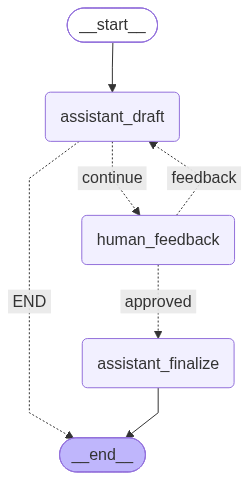

In [568]:
from IPython.display import Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [569]:
config = {"configurable": {"thread_id": "1"}}
result = graph.invoke(
    {
        "question": "What is Morroocan President ?",
        "response": "",
        "user_feedback": "",
        "status": ""
    },
    config=config
)

assistant_draft ...
assistant_draft_router ...
human_feedback ...
feedback_router ...
assistant_draft ...
assistant_draft_router ...


In [570]:
from IPython.display import Markdown
display(Markdown(result.get("response")))

Morrco is not a country I am aware of.  I believe you may be referring to Morocco. 

Morocco is a developing country with a mixed economy. While it has made significant progress in recent years, it still faces several challenges that contribute to poverty. Here are some reasons:

1. **Unemployment**: Morocco has a high unemployment rate, particularly among young people. This can lead to poverty and social unrest.
2. **Income inequality**: Morocco has a significant wealth gap between the rich and the poor. The wealthy tend to hold most of the country's wealth, leaving the poor with limited access to resources and opportunities.
3. **Limited economic opportunities**: Morocco's economy is largely dependent on agriculture, which is vulnerable to climate change, drought, and other environmental factors. This can lead to food insecurity and poverty.
4. **Corruption**: Corruption is a significant issue in Morocco, which can lead to unequal distribution of resources and opportunities, perpetuating poverty.
5. **Lack of access to education and healthcare**: Many Moroccans, particularly in rural areas, lack access to quality education and healthcare, which can limit their opportunities for economic mobility and perpetuate poverty.
6. **Dependence on foreign aid**: Morocco relies heavily on foreign aid, which can create a culture of dependency and limit the country's ability to develop its own economic solutions to poverty.
7. **Climate change**: Morocco is vulnerable to climate change, which can lead to drought, water scarcity, and food insecurity, all of which can exacerbate poverty.

To address these challenges, the Moroccan government has implemented various initiatives, such as:

1. **Investing in education and healthcare**: The government has invested in improving access to quality education and healthcare, particularly in rural areas.
2. **Promoting economic development**: The government has implemented policies to promote economic development, such as investing in infrastructure and supporting small and medium-sized enterprises.
3. **Reducing corruption**: The government has implemented measures to reduce corruption, such as increasing transparency and accountability in government institutions.
4. **Addressing climate change**: The government has implemented initiatives to address climate change, such as investing in renewable energy and promoting sustainable agriculture practices.

These are just a few examples of the challenges and initiatives related to poverty in Morocco. If you have any specific questions or would like more information, please let me know.